In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Rescaling, Dense, Input, GlobalAveragePooling2D, RandomFlip, RandomRotation
import tensorflow as tf
import keras_tuner as kt
import numpy as np
import os
from model import build_model
from shutil import copyfile, rmtree
print(tf.__version__)

2.20.0


In [ ]:
def create_dirs(main_dir):
    try:
        os.mkdir(main_dir + '/temp')
        os.mkdir(main_dir + '/temp/train')
        os.mkdir(main_dir + '/temp/test')
        os.mkdir(main_dir + '/temp/cross_validation')
    except os.OSError:
        print('Error failed to make directory')

def drop_dirs(main_dir):
    try:
        rmtree(main_dir + '/temp', ignore_errors=True)
    except OSError:
        print('Error failed to drop directory')


# def split_file(main_dir, split_train_rate):
#     files = []
#     rng = np.random.default_rng()
#     initial_path = main_dir + '/'
#     temp_dir = 'temp'

#     for file in os.listdir(main_dir):
#         # check file size
#         if os.path.getsize(os.path.join(main_dir,file)) and file != "temp":
#             files.append(file)
#     files = np.array(files)
#     # shuffled = random.sample(files, len(files))
#     rng.shuffle(files)
#     split_index = int(split_train_rate * len(files))
#     cross_validation_index = int(split_index + (len(files) - split_index) / 2)

    # for index, file in enumerate(files):
    #     sub_dir = "test"
    #     if index < split_index:
    #         sub_dir = "train"
    #     elif split_index < index and index < cross_validation_index:
    #         sub_dir = "cross_validation"
    #     file_path = os.path.join(main_dir,file)
    #     if os.path.exists(file_path):
    #         print(file_path, os.path.join(main_dir,temp_dir,sub_dir,file), file)
            # copyfile(file_path, os.path.join(main_dir,temp_dir,sub_dir,file))

    # train_set = files[:split_index]
    # cross_validation_set = files[split_index:cross_validation_index]
    # test_set = files[cross_validation_index:]
    # return (split_index,cross_validation_index)

In [75]:
create_dirs('data/Cat')
# drop_dirs('data/Cat')

In [ ]:
# train_index, cross_validation_index = split_file('./data/Cat', 0.8)
# print(train_index, cross_validation_index)

./data/Cat/7849.jpg ./data/Cat/temp/train/7849.jpg 7849.jpg
./data/Cat/11324.jpg ./data/Cat/temp/train/11324.jpg 11324.jpg
./data/Cat/3123.jpg ./data/Cat/temp/train/3123.jpg 3123.jpg
./data/Cat/9695.jpg ./data/Cat/temp/train/9695.jpg 9695.jpg
./data/Cat/1725.jpg ./data/Cat/temp/train/1725.jpg 1725.jpg
./data/Cat/6584.jpg ./data/Cat/temp/train/6584.jpg 6584.jpg
./data/Cat/10675.jpg ./data/Cat/temp/train/10675.jpg 10675.jpg
./data/Cat/4472.jpg ./data/Cat/temp/train/4472.jpg 4472.jpg
./data/Cat/10702.jpg ./data/Cat/temp/train/10702.jpg 10702.jpg
./data/Cat/3975.jpg ./data/Cat/temp/train/3975.jpg 3975.jpg
./data/Cat/12061.jpg ./data/Cat/temp/train/12061.jpg 12061.jpg
./data/Cat/1112.jpg ./data/Cat/temp/train/1112.jpg 1112.jpg
./data/Cat/1174.jpg ./data/Cat/temp/train/1174.jpg 1174.jpg
./data/Cat/8937.jpg ./data/Cat/temp/train/8937.jpg 8937.jpg
./data/Cat/686.jpg ./data/Cat/temp/train/686.jpg 686.jpg
./data/Cat/10258.jpg ./data/Cat/temp/train/10258.jpg 10258.jpg
./data/Cat/733.jpg ./data/Ca

In [2]:
# main_dir = pathlib.Path('./data/Cat')
# print(main_dir)
(train_ds,validation_ds) = tf.keras.preprocessing.image_dataset_from_directory(
    './data',
    validation_split=0.2,
    subset="both",
    # label_mode = 'binary',
    seed=123,
    batch_size=64,
    image_size=(150,150),
)
split_validation_index = len(validation_ds) // 2
test_ds = validation_ds.skip(split_validation_index)
validation_ds = validation_ds.take(split_validation_index)
print(len(train_ds), len(validation_ds), len(test_ds))

Found 24998 files belonging to 2 classes.
Using 19999 files for training.
Using 4999 files for validation.
313 39 40


In [35]:
class_names = train_ds.class_names
print(class_names)

['Cat', 'Dog']


(128, 150, 150, 3)
(128,)
(128, 150, 150, 3)
(128,)
(128, 150, 150, 3)
(128,)
(128, 150, 150, 3)
(128,)
(128, 150, 150, 3)
(128,)
(128, 150, 150, 3)
(128,)
(128, 150, 150, 3)
(128,)
(128, 150, 150, 3)
(128,)
(128, 150, 150, 3)
(128,)


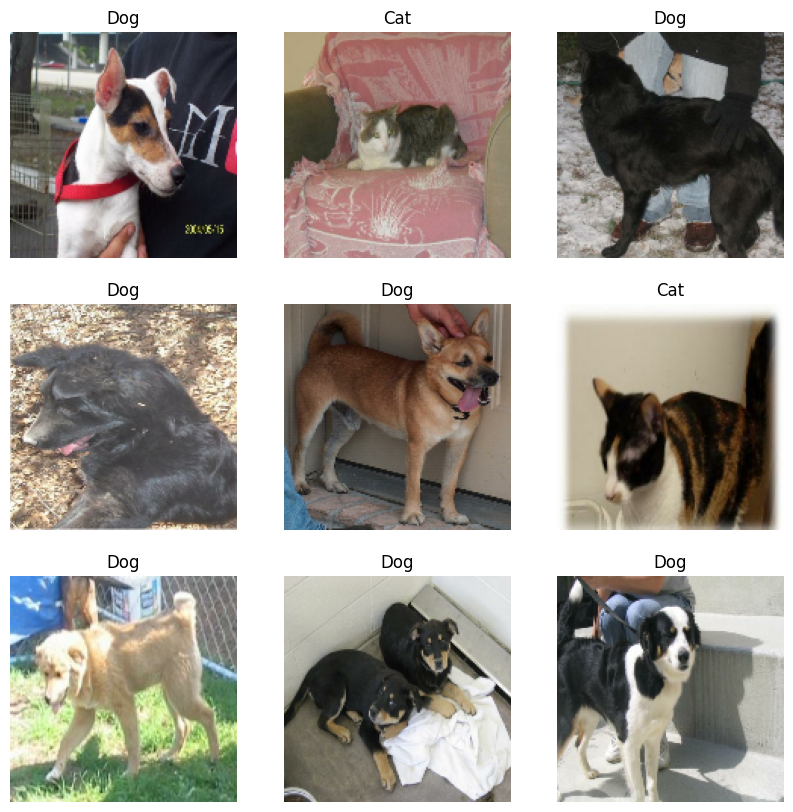

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in test_ds.take(1):
  for i in range(9):
    print(images.shape)
    print(labels.shape)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [28]:
from PIL import Image

dataset_dir = "data/Dog"

for root, _, files in os.walk(dataset_dir):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg')):
            img_path = os.path.join(root, file)
            try:
                with Image.open(img_path) as img:
                    img.verify() # First check if PIL catches structural issues
                
                # Force open and resave to strip extraneous bytes
                with Image.open(img_path) as img:
                    img.convert('RGB').save(img_path, 'JPEG')
            except Exception as e:
                print(file, "is completely broken. Deleting...")
                os.remove(img_path)

/Users/dungtc/Programming/dl-labs/.venv/lib/python3.10/site-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


11702.jpg is completely broken. Deleting...


In [36]:
model = Sequential([
    Rescaling(1./255, input_shape=(150, 150, 3)),
    Conv2D(32, (3,3), activation='relu'), # 148
    MaxPooling2D(), # 74
    Conv2D(64, (3,3), activation='relu'), # 72
    MaxPooling2D(), # 36
    Conv2D(128, (3,3), activation='relu'), # 34
    MaxPooling2D(), # 17
    Flatten(),
    Dense(128, activation='relu'),
    Dense(2, activation='softmax'),
])

/Users/dungtc/Programming/dl-labs/.venv/lib/python3.10/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [3]:
# number to train => 1 + log base of factor by max_epochs = 1 + log 3 (10)
tuner = kt.Hyperband(hypermodel=build_model, objective='val_accuracy', max_epochs=5,factor=3,directory='logs',project_name='cnn_tuning')

/Users/dungtc/Programming/dl-labs/.venv/lib/python3.10/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [4]:
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

In [5]:
tuner.search(train_ds, epochs=2, validation_data=validation_ds, callbacks=[stop_early])

Trial 7 Complete [00h 15m 09s]
val_accuracy: 0.7047275900840759

Best val_accuracy So Far: 0.739182710647583
Total elapsed time: 01h 16m 03s

Search: Running Trial #8

Value             |Best Value So Far |Hyperparameter
64                |128               |units
0.1               |0.2               |dropout
0.00013812        |0.00098025        |learning_rate
2.21e-05          |0.00017881        |weight_decay
5                 |5                 |tuner/epochs
0                 |2                 |tuner/initial_epoch
0                 |1                 |tuner/bracket
0                 |1                 |tuner/round

Epoch 1/5
 19/313 ━━━━━━━━━━━━━━━━━━━━ 4:23 897ms/step - accuracy: 0.5338 - loss: 0.7845

KeyboardInterrupt: 

In [7]:
tuner.results_summary(num_trials=7)

# 2. Extract the absolute best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"Optimal Dense units: {best_hps.get('units')}")
print(f"Optimal Learning Rate: {best_hps.get('learning_rate')}")
print(f"Optimal Dropout: {best_hps.get('dropout')}")
print(f"Optimal Weight Decay: {best_hps.get('weight_decay')}")

Results summary
Results in logs/cnn_tuning
Showing 7 best trials
Objective(name="val_accuracy", direction="max")

Trial 0005 summary
Hyperparameters:
units: 128
dropout: 0.2
learning_rate: 0.0009802547951476774
weight_decay: 0.0001788114586587675
tuner/epochs: 5
tuner/initial_epoch: 2
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0004
Score: 0.739182710647583

Trial 0006 summary
Hyperparameters:
units: 128
dropout: 0.30000000000000004
learning_rate: 0.0008344927783867745
weight_decay: 4.364244877589065e-05
tuner/epochs: 5
tuner/initial_epoch: 2
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0001
Score: 0.7047275900840759

Trial 0004 summary
Hyperparameters:
units: 128
dropout: 0.2
learning_rate: 0.0009802547951476774
weight_decay: 0.0001788114586587675
tuner/epochs: 2
tuner/initial_epoch: 0
tuner/bracket: 1
tuner/round: 0
Score: 0.6814903616905212

Trial 0001 summary
Hyperparameters:
units: 128
dropout: 0.30000000000000004
learning_rate: 0.0008344927783867745
weight_decay: 4.3642448

In [9]:
# 3. Retrain the model using the optimal settings
model = tuner.hypermodel.build(best_hps)

/Users/dungtc/Programming/dl-labs/.venv/lib/python3.10/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [37]:
model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['accuracy'])

In [ ]:
model.load_weights('cat_dog_classifer.weights.h5')
print("Weights loaded! The model is ready to evaluate or predict.")

In [11]:
cb = tf.keras.callbacks.ModelCheckpoint(filepath='./cp.weights.h5', save_weights_only=True, verbose=1)

history = model.fit(
  train_ds,
  validation_data=validation_ds,
  epochs=3,
  callbacks=[cb]
)

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 947ms/step - accuracy: 0.6030 - loss: 0.6717
Epoch 1: saving model to ./cp.weights.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 306s 970ms/step - accuracy: 0.6321 - loss: 0.6431 - val_accuracy: 0.4832 - val_loss: 0.8725
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 898ms/step - accuracy: 0.6760 - loss: 0.5966
Epoch 2: saving model to ./cp.weights.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 288s 919ms/step - accuracy: 0.6850 - loss: 0.5878 - val_accuracy: 0.6715 - val_loss: 0.6286
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 893ms/step - accuracy: 0.7085 - loss: 0.5602
Epoch 3: saving model to ./cp.weights.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 287s 916ms/step - accuracy: 0.7184 - loss: 0.5509 - val_accuracy: 0.5681 - val_loss: 0.7885


In [50]:
test_loss, test_acc = model.evaluate(test_ds, verbose=2)
print('\nTest accuracy:', test_acc)

20/20 - 14s - 696ms/step - accuracy: 0.8036 - loss: 1.2232

Test accuracy: 0.8036080598831177


In [51]:
predictions = model.predict(test_ds)

20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 575ms/step


In [52]:
predictions_max = np.argmax(predictions, axis=1)

In [54]:
print(predictions)
print(predictions_max)

[[8.4508305e-05 9.9991554e-01]
 [9.9999774e-01 2.2273216e-06]
 [2.4291282e-03 9.9757087e-01]
 ...
 [2.7602598e-09 1.0000000e+00]
 [8.1555281e-06 9.9999189e-01]
 [2.8937026e-03 9.9710625e-01]]
[1 0 1 ... 1 1 1]


In [61]:
checkpoint_path = 'save/cp-{epoch:04d}.weights.h5'

In [62]:
model.save_weights(checkpoint_path.format(epoch=0))
print('Weights are saved successfully')

Weights are saved successfully


In [56]:
# Saves everything into a native Keras file format
model.save('cat_dog_classifer.keras')